<details>
  <summary><strong>MIT License (click to expand)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# Classification of Accelerometer Sensor Data (Classification Model Using a Recurrent Neural Network)




The goal of this hands-on session is to give you a feel for the workflow of building a **Recurrent Neural Network (RNN)**, one type of deep learning model.

In a recurrent neural network, the hidden state produced when previous data was input is also used to generate the output.
It is one of the candidate models when you want to obtain some output from time-series data as input.

<br>

Conceptual diagram of a Recurrent Neural Network (RNN):
<br>
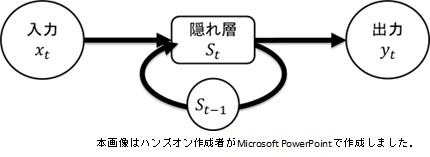




<br>






## Objective: Classify smartwatch gestures using accelerometer sensor data

<br>

The goal of this hands-on session is to **classify which of 20 types of gestures was performed, based on time-series data acquired from an accelerometer**.

You may not be familiar with accelerometers, but for example, smartphones use them to detect gravitational acceleration (the direction of gravity), which is then used to rotate the screen orientation.

<br>

In this hands-on session, we use the [SmartWatch Gestures Dataset](https://tev.fbk.eu/resources/smartwatch).
This dataset was collected to evaluate gesture recognition algorithms, with the aim of using arm-based gestures as input for mobile applications. It consists of a total of 3,200 sets of time-series data, with 8 subjects each performing 20 types of gestures 20 times.

<br>

Each time-series record contains XYZ acceleration data obtained from the 3-axis accelerometer of a first-generation Sony SmartWatch(TM), along with multiple timestamps from time sources available on Android devices.

<br>

Note that the "start" and "end" of each time-series record are determined by a **manual operation** in which the subject taps the smartwatch screen at the very beginning and the very end of the gesture.

(**Note: this means that extra arm-swinging motions other than the actual gesture may be included immediately after the start or just before the end!**)

---
[TensorFlow Dataset]
* [smartwatch_gestures](https://www.tensorflow.org/datasets/catalog/smartwatch_gestures)

[Papers]
* G. Costante, L. Porzi, O. Lanz, P. Valigi, E. Ricci, [Personalizing a Smartwatch-based Gesture Interface With Transfer Learning](http://www.eurasip.org/Proceedings/Eusipco/Eusipco2014/HTML/papers/1569922319.pdf), 22nd European Signal Processing Conference, EUSIPCO 2014
* L. Porzi and S. Messelodi and C.M. Modena and E. Ricci: [A Smart Watch-based Gesture Recognition System for Assisting People with Visual Impairments.](https://dl.acm.org/doi/10.1145/2505483.2505487) ACM International Workshop on Interactive Multimedia on Mobile and Portable Devices  - IMMPD, Barcelona, Spain, 2013




## Checking the TensorFlow version

This notebook does not use a GPU.

In [1]:
import tensorflow as tf
import sklearn
import scipy
import os


# Install libraries that are not preinstalled in Colab
!pip install -q japanize_matplotlib # External library for displaying Japanese text in matplotlib


print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)
print('scipy version:',scipy.__version__)

restart_flag = False

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True

if sklearn.__version__ != '1.6.1':
    !pip install -q --upgrade scikit-learn==1.6.1
    print('scikit-learn version:',sklearn.__version__)
    restart_flag = True

if scipy.__version__ != '1.16.3':
    !pip install -q --upgrade scipy==1.16.3
    print('scipy version:',scipy.__version__)
    restart_flag = True

# The block below runs only when a library version has been changed.
if restart_flag :
    print("If a library version was changed, the runtime will be restarted automatically.")
    print("In Colab, a warning saying 'crashed for an unknown reason' may appear in the lower-left corner,")
    print("but you can ignore it and run the following code cells.")
    # We intentionally crash the runtime to force a restart.
    get_ipython().kernel.do_shutdown(restart=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 31.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TensorFlow version: 2.20.0
scikit-learn version: 1.6.1
scipy version: 1.16.3


### Package imports

In [2]:
import os # os: standard library, handles OS-dependent operations (environment variables, folder creation, etc.)
import datetime # datetime: standard library, handles date-related data
import random # random: standard library, pseudo-random number generator
import numpy as np # numpy: a library for numerical computation
import pandas as pd # pandas: a library for tabular data
from IPython.display import display # A function to display certain data more cleanly than print() in Colab, etc.
import matplotlib.pylab as plt # matplotlib: a library for drawing graphs
import seaborn as sns # seaborn: a library for drawing graphs
# tensorboard: settings for the dashboard output of the deep learning library TensorFlow
%load_ext tensorboard
import tensorflow as tf # TensorFlow: a deep learning library

import japanize_matplotlib # External library for displaying Japanese text in matplotlib

import tensorflow_datasets as tfds # A library for handling the datasets published by TensorFlow
import scipy # scipy: a library for scientific and technical computation
import plotly.express as px # plotly: a library for drawing graphs


### Fixing the random seed of the pseudo-random number generator

* This fixes the sequence of pseudo-random numbers generated and used in the program below.
* The random seed is the number used to initialize the pseudo-random number generator.
* If not specified explicitly, it is initialized using the current time, etc.
* This time, we fix the random seed to ensure reproducibility (so that anyone running it at any time will get the same pseudo-random sequence).

<small> Note: In Colab, complete reproducibility may not be possible due to differences in the allocated CPU/GPU and library versions.</small>

In [3]:
def set_seed(seed=123):
    # Fix the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # External Python library: make TensorFlow neural networks operate deterministically
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # External Python library: make TensorFlow neural networks operate deterministically
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python standard library: fix the seed of random
    random.seed(seed)
    # External Python library: fix the seed of NumPy
    np.random.seed(seed)
    # External Python library: fix the seed of TensorFlow
    tf.random.set_seed(seed)

set_seed(42)


## Obtaining the dataset and splitting it into training / validation / test sets

In [4]:
# Estimated execution time: 1-2 minutes

# Obtain the dataset from the TensorFlow Datasets catalog,
# and split it into training / validation / test sets.
raw_train_ds, raw_valid_ds, raw_test_ds = tfds.load('smartwatch_gestures', split=['train[:70%]', 'train[70%:90%]','train[90%:]'], shuffle_files=False)

# Check the number of records in each dataset.
print()
print(f"  Number of records in the training dataset:   {raw_train_ds.cardinality().numpy()}")
print(f"  Number of records in the validation dataset: {raw_valid_ds.cardinality().numpy()}")
print(f"  Number of records in the test dataset:       {raw_test_ds.cardinality().numpy()}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/smartwatch_gestures/incomplete.HBRPOI_1.0.0/smartwatch_gestures-train.tfre…

Dataset smartwatch_gestures downloaded and prepared to /root/tensorflow_datasets/smartwatch_gestures/1.0.0. Subsequent calls will reuse this data.

  Number of records in the training dataset:   2276
  Number of records in the validation dataset: 650
  Number of records in the test dataset:       325


#### Let's take a look at the contents of the obtained dataset.

In [5]:
# View the contents of the obtained dataset

# Take a look at the data at the specified index of the test dataset.
index = 0
for x in raw_test_ds.take(index+1):
    display(x)


{'attempt': <tf.Tensor: shape=(), dtype=uint8, numpy=16>,
 'features': {'accel_x': <tf.Tensor: shape=(22,), dtype=float64, numpy=
  array([-5.05655384, -2.60489202, -1.83874702, -1.37906003, -2.91134906,
         -4.90332508, -1.83874702,  2.60489202, 10.87925243, 15.93580627,
          9.34696388,  8.58081913,  8.1211319 ,  8.58081913,  8.58081913,
          7.96790314,  8.42759037,  8.42759037,  8.88727665,  8.27436161,
          6.89530087,  9.04050541])>,
  'accel_y': <tf.Tensor: shape=(22,), dtype=float64, numpy=
  array([ 7.96790314,  9.6534214 , 14.55674553,  7.20175886, -2.14520502,
         -2.60489202, -1.37906003, -1.68551803, -1.22583103, -4.44363785,
         -2.45166302, -3.21780705, -5.05655384, -1.99197602, -1.83874702,
         -1.99197602, -3.37103605, -3.21780705, -3.37103605, -2.60489202,
         -8.88727665, -8.1211319 ])>,
  'accel_z': <tf.Tensor: shape=(22,), dtype=float64, numpy=
  array([ 2.45166302,  1.83874702,  2.45166302,  4.59686708,  9.50019264,
        

## Overview of the dataset (gesture types and the accelerometer)

The data columns stored in this dataset are summarized in the table below.

| Column No. | Column name | Translation | Overview |
|----|----|----|---|
|0|attempt|attempt|ID of each gesture time-series record|
|1|features/accel_x|acceleration_X-axis|Accelerometer time-series data (X-axis)|
|2|features/accel_y|acceleration_Y-axis|Accelerometer time-series data (Y-axis)|
|3|features/accel_z|acceleration_Z-axis|Accelerometer time-series data (Z-axis)|
|4|features/time_event|device uptime [nanoseconds]|Relative time obtained from the sensor [nanoseconds], in increments of 1/1,000,000,000 of a second|
|5|features/time_millis|time [milliseconds]|[UNIX time](https://en.wikipedia.org/wiki/Unix_time) [milliseconds], in increments of 1/1,000 of a second|
|6|features/nanos|system uptime [nanoseconds]|Relative time obtained from the software [nanoseconds], in increments of 1/1,000,000,000 of a second|
|7|gesture|gesture (hand motion)| Number identifying each of the 20 gesture types (1 to 20)|
|8|participant|participant| Number identifying each of the 8 subjects; not used this time.|



The accelerometer data has X-, Y-, and Z-axes, but they are arranged as shown in the figure below, so **note that "up" changes depending on how the watch is worn and how the wrist/arm is twisted**.


Conceptual diagram of the smartwatch's 3-axis accelerometer:

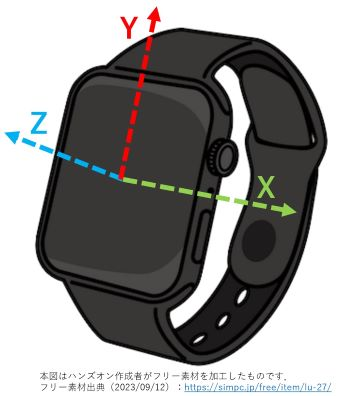


<small>Note: The orientation of the axes may differ depending on the type of smartwatch.</small>

An illustration showing the 20 types of gestures is given below. Note that the smartwatch is worn on the subject's right wrist.

Conceptual diagram of the 20 gestures:

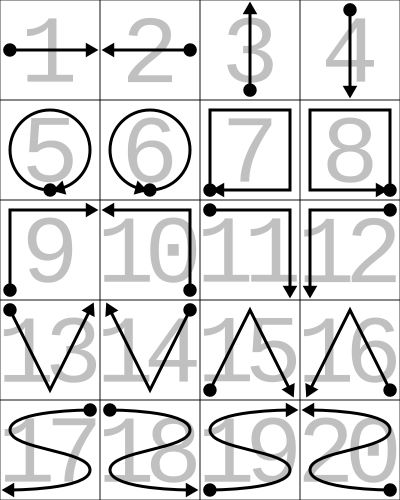

SmartWatch Gesture  (Aug. 31, 2023, 00:30 UTC). In Technologies of Vision (TeV) : The Research Unit included in the Digital Industry Center of Fondazione Bruno Kessler. Retrieved from https://tev.fbk.eu/resources/smartwatch

## Example of visualizing the obtained data

Because it is hard to grasp the motion just by visualizing the "acceleration" information in a graph, we visualize the data after double-integrating the acceleration to obtain "displacement" information.

In [6]:
# Specify the index of the dataset record to visualize.
index = 0


# Time integration (using Simpson's rule for approximation since the values are discrete)
def time_integrator_simpson(time, dx):
    x = []
    x.append(0.0)
    for i in range(0, len(dx)-1):
        if i==0:
            temp = scipy.integrate.simpson(y=np.array([0,dx[i],dx[i+1]]), x=np.array([0,time[i],time[i+1]]) )
        else:
            temp = scipy.integrate.simpson(y=np.array([dx[i-1],dx[i],dx[i+1]]), x=np.array([time[i-1],time[i],time[i+1]]) )
        x.append(temp)
    return x



for i, raw_data in  enumerate(raw_test_ds.take(index+1)):
    if i == index:

        #display(raw_data)

        # Time data in milliseconds (extracted from the dataset)
        time_millis = raw_data['features']['time_millis']
        # Set the start time of each time-series record to 0 seconds, and convert the time data from milliseconds to seconds
        time_secs = tf.cast((time_millis - time_millis[0]), dtype='float64')*10**(-3)

        # X, Y, Z acceleration data (extracted from the dataset)
        acc_x = raw_data['features']['accel_x'].numpy()
        acc_y = raw_data['features']['accel_y'].numpy()
        acc_z = raw_data['features']['accel_z'].numpy()

        # Integrate the X, Y, Z accelerations to compute the X, Y, Z velocities
        velocity_x = time_integrator_simpson(time_secs, acc_x.tolist())
        velocity_y = time_integrator_simpson(time_secs, acc_y.tolist())
        velocity_z = time_integrator_simpson(time_secs, acc_z.tolist())

        # Integrate the X, Y, Z velocities to compute the X, Y, Z displacements
        disp_x = time_integrator_simpson(time_secs, velocity_x)
        disp_y = time_integrator_simpson(time_secs, velocity_y)
        disp_z = time_integrator_simpson(time_secs, velocity_z)

        # The correct (ground-truth) label for this time, i.e., the gesture number (extracted from the dataset)
        gesture_label =raw_data['gesture'].numpy()


# Create a DataFrame for checking the data
df = pd.DataFrame(data={"Integrated Disp. X [m]":disp_x,"Integrated Disp. Y [m]":disp_y, "Integrated Disp. Z [m]":disp_z, \
                        "time[sec]":time_secs, "Gesture label":gesture_label, \
                        "Accel. X [m/s²]":acc_x, "Accel. Y [m/s²]":acc_y, "Accel. Z [m/s²]":acc_z, "UNIX time[ms]":time_millis})

# Check the data
print("Check the data before and after conversion:")
display(df)

# Check the displacement data in a 3D graph
df_min = df.loc[:,["Integrated Disp. X [m]","Integrated Disp. Y [m]","Integrated Disp. Z [m]"]].min().min()
df_max = df.loc[:,["Integrated Disp. X [m]","Integrated Disp. Y [m]","Integrated Disp. Z [m]"]].max().max()
range_min = df_min - 0.1 * np.abs( df_max - df_min )
range_max = df_max + 0.1 * np.abs( df_max - df_min )

fig = px.scatter_3d(df, x='Integrated Disp. X [m]', y='Integrated Disp. Y [m]', z='Integrated Disp. Z [m]', color='time[sec]',
                    range_x=(range_min, range_max),
                    range_y=(range_min, range_max),
                    range_z=(range_min, range_max),
                    template='plotly_dark',
                    color_continuous_scale='Viridis',
                    title = f"XYZ displacement data obtained by double-integrating XYZ acceleration data (Gesture label:{gesture_label})"
)


fig.add_traces(
    list(px.line_3d(df, x='Integrated Disp. X [m]', y='Integrated Disp. Y [m]', z='Integrated Disp. Z [m]',
                    range_x=(range_min, range_max),
                    range_y=(range_min, range_max),
                    range_z=(range_min, range_max),
                    template='plotly_dark'
).select_traces())
)


fig.update_layout(
    scene = dict(
        aspectmode='cube',
        xaxis = dict(range=[range_min, range_max]),
        yaxis = dict(range=[range_min, range_max]),
        zaxis = dict(range=[range_min, range_max]),
    ),
    template='plotly_dark'
)

fig.show()

!mkdir -p plots
fig.write_html("./plots/2026_06_scatter_3d_en.html", include_plotlyjs=True,full_html=True, auto_open=False)

Check the data before and after conversion:


,Integrated Disp. X [m],Integrated Disp. Y [m],Integrated Disp. Z [m],time[sec],Gesture label,Accel. X [m/s²],Accel. Y [m/s²],Accel. Z [m/s²],UNIX time[ms]
0,0.000000,0.000000,0.000000,0.000,10,-5.056554,7.967903,2.451663,1384249557539
1,-0.003502,0.012978,0.002472,0.110,10,-2.604892,9.653421,1.838747,1384249557649
2,-0.038183,0.137748,0.027060,0.222,10,-1.838747,14.556746,2.451663,1384249557761
3,-0.114043,0.453043,0.092158,0.333,10,-1.379060,7.201759,4.596867,1384249557872
4,-0.100553,0.555711,0.148687,0.445,10,-2.911349,-2.145205,9.500193,1384249557984
5,-0.097097,0.326267,0.258316,0.556,10,-4.903325,-2.604892,6.895301,1384249558095
6,-0.146895,0.015266,0.368914,0.668,10,-1.838747,-1.379060,1.685518,1384249558207
7,-0.173457,-0.096428,0.305420,0.780,10,2.604892,-1.685518,2.145205,1384249558319
8,-0.072260,-0.078096,0.153367,0.868,10,10.879252,-1.225831,11.492168,1384249558407
9,0.148601,-0.066076,0.192443,0.978,10,15.935806,-4.443638,19.000385,1384249558517


If the graph is not displayed: [Open the PNG file on GitHub](https://github.com/arch-inform-kaken-group/ai-course-notebooks/tree/main/notebooks/en_2026/plots/2026_06_scatter_3d_en.png)

The displacement data is visualized for index=0, which is a gesture with label 10.

Excluding the start and end, you can see it traces out the "upside-down L-shape" gesture corresponding to label 10.

The displacement data was computed for visualization, but the input to the RNN does not use displacement data; it uses the **acceleration data**.

## Data preprocessing before feeding the RNN model

We extract only the data columns used for training the model, convert units, and process the ground-truth label data.

The processing this time consists of the following:

[Input data]
 * Convert from "[UNIX time](https://en.wikipedia.org/wiki/Unix_time)" to "elapsed time since the start of the gesture"
 * Convert data in milliseconds to data in seconds

[Output data (ground-truth labels)]
* Convert the gesture label, which is a number from 1 to 20, into a one-hot label
* Duplicate it to match the length of each time-series record



In [7]:
# Extract only the data columns used for training the model, convert units, and process the ground-truth label data.


# Training dataset
ds_train_col = raw_train_ds.map(lambda data: [tf.transpose([tf.cast(data['features']['accel_x'],dtype='float64'),\
                                                tf.cast(data['features']['accel_y'],dtype='float64'),\
                                                tf.cast(data['features']['accel_z'],dtype='float64'),\
                                                # Set the start time of each time-series record to 0 seconds, and convert the time data from milliseconds to seconds
                                                tf.cast(data['features']['time_millis']-tf.math.reduce_min(data['features']['time_millis']),dtype='float64')*10**(-3)], \
                                      perm=[1,0]),
                                      # Convert to a one-hot label and duplicate it to match the length of each time-series record
                                      tf.one_hot(tf.repeat(data['gesture'],len(data['features']['time_millis']), axis=-1),20)])
ds_train = ds_train_col.shuffle(1024).padded_batch(128)


# Validation dataset
ds_valid_col = raw_valid_ds.map(lambda data: [tf.transpose([tf.cast(data['features']['accel_x'],dtype='float64'),\
                                                tf.cast(data['features']['accel_y'],dtype='float64'),\
                                                tf.cast(data['features']['accel_z'],dtype='float64'),\
                                                # Set the start time of each time-series record to 0 seconds, and convert the time data from milliseconds to seconds
                                                tf.cast(data['features']['time_millis']-tf.math.reduce_min(data['features']['time_millis']),dtype='float64')*10**(-3)], \
                                      perm=[1,0]),
                                      # Convert to a one-hot label and duplicate it to match the length of each time-series record
                                      tf.one_hot(tf.repeat(data['gesture'],len(data['features']['time_millis']), axis=-1),20)])
ds_valid = ds_valid_col.padded_batch(128)


# Test dataset
ds_test_col = raw_test_ds.map(lambda data: [tf.transpose([tf.cast(data['features']['accel_x'],dtype='float64'),\
                                                tf.cast(data['features']['accel_y'],dtype='float64'),\
                                                tf.cast(data['features']['accel_z'],dtype='float64'),\
                                                # Set the start time of each time-series record to 0 seconds, and convert the time data from milliseconds to seconds
                                                tf.cast(data['features']['time_millis']-tf.math.reduce_min(data['features']['time_millis']),dtype='float64')*10**(-3)], \
                                      perm=[1,0]),
                                      # Convert to a one-hot label and duplicate it to match the length of each time-series record
                                      tf.one_hot(tf.repeat(data['gesture'],len(data['features']['time_millis']), axis=-1),20)])
ds_test = ds_test_col.padded_batch(128)



# With batch size 1, take a look at the data in the first batch.
print("Example output:")
for data in ds_test_col.padded_batch(1).take(1):
    print(data)


Example output:
(<tf.Tensor: shape=(1, 22, 4), dtype=float64, numpy=
array([[[-5.05655384,  7.96790314,  2.45166302,  0.        ],
        [-2.60489202,  9.6534214 ,  1.83874702,  0.11      ],
        [-1.83874702, 14.55674553,  2.45166302,  0.222     ],
        [-1.37906003,  7.20175886,  4.59686708,  0.333     ],
        [-2.91134906, -2.14520502,  9.50019264,  0.445     ],
        [-4.90332508, -2.60489202,  6.89530087,  0.556     ],
        [-1.83874702, -1.37906003,  1.68551803,  0.668     ],
        [ 2.60489202, -1.68551803,  2.14520502,  0.78      ],
        [10.87925243, -1.22583103, 11.49216843,  0.868     ],
        [15.93580627, -4.44363785, 19.00038528,  0.978     ],
        [ 9.34696388, -2.45166302, 12.25831318,  1.089     ],
        [ 8.58081913, -3.21780705,  8.27436161,  1.2       ],
        [ 8.1211319 , -5.05655384,  4.59686708,  1.312     ],
        [ 8.58081913, -1.99197602,  6.12915707,  1.423     ],
        [ 8.58081913, -1.83874702,  5.66946983,  1.54      ],
 

## Defining and training the RNN model

Data fed to the model:

 * X-axis acceleration
 * Y-axis acceleration
 * Z-axis acceleration
 * Elapsed time (in seconds) since the start of the gesture

Data output by the model:

 * Gesture type label (20 classes)

In [8]:
# Input the 4 types of data: [ X-axis acceleration, Y-axis acceleration, Z-axis acceleration, time(sec) ]
num_features = 4

# Input layer: (time length x features channel)
inputs = tf.keras.layers.Input(shape = (None, num_features), name = 'input')

# (batch_size, time length, features) -> (batch_size, time, rnn_units)
x = tf.keras.layers.SimpleRNN(units=512, return_sequences=True, name='rnn')(inputs)

# (batch, time length, rnn_units) ->  (batch, time length, features)
# The output is the probability for each of the 20 gesture classes, so the number of units in the output layer is 20.
outputs = tf.keras.layers.Dense( units= 20, activation='softmax')(x)

# Define the model
model = tf.keras.Model( inputs = inputs, outputs = outputs, name = 'rnn_model' )

# Output the structure of the model as text
model.summary()


Model: "rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, None, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, None, 512)      │       264,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 20)       │        10,260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,964 (1.05 MB)

 Trainable params: 274,964 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Prepare to create a log file during training
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_rnn.csv'))

# Prepare to create a TensorBoard log
os.makedirs('/contents/logs/fit/', exist_ok=True) # Create the folder
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

callbacks.append(tensorboard_callback)


# Compile the model (configure the optimization algorithm, loss function, evaluation metrics, etc.)
model.compile(loss=tf.losses.CategoricalCrossentropy(), # Loss function
                   optimizer=tf.optimizers.Adam(), # Optimization algorithm
                   metrics=[tf.keras.metrics.CategoricalAccuracy(), # Monitoring metric (does not affect the training of the model itself)
                            ]
              )

# Train the model (about 4 minutes on CPU)
history = model.fit(ds_train,
                    validation_data=ds_valid,
                    epochs = 30,
                    callbacks = callbacks
                    )


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step - categorical_accuracy: 0.0786 - loss: 1.5608 - val_categorical_accuracy: 0.1195 - val_loss: 1.3780
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 339ms/step - categorical_accuracy: 0.1619 - loss: 1.2327 - val_categorical_accuracy: 0.1812 - val_loss: 1.0747
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - categorical_accuracy: 0.2329 - loss: 0.9588 - val_categorical_accuracy: 0.2468 - val_loss: 0.8888
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step - categorical_accuracy: 0.2742 - loss: 0.8073 - val_categorical_accuracy: 0.2880 - val_loss: 0.7865
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 326ms/step - categorical_accuracy: 0.3207 - loss: 0.6761 - val_categorical_accuracy: 0.3365 - val_loss: 0.7041
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 263ms/step - categorical_accuracy: 0.3675 - loss: 0.5938 - val_categorical_accuracy: 0.3812 - val_loss: 0.5446
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 341ms/step - categorical_accuracy: 0.3779 - los

## Training progress of the RNN model

In [ ]:
log_df = pd.read_csv('training_log_rnn.csv')

epochs = log_df["epoch"].values

train_loss = log_df["loss"].values
train_acc = log_df['categorical_accuracy'].values

valid_loss = log_df["val_loss"].values
valid_acc = log_df['val_categorical_accuracy'].values


fig, axes = plt.subplots(1,2, figsize=(13,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")


axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].legend(loc="upper right")
axes[1].set_title("accuracy")

plt.show()


## Evaluating the trained RNN model

In [ ]:
# Accuracy across the entire time-series for each gesture
print(f'Accuracy on the training dataset:   {model.evaluate(ds_train)[1]}\n')
print(f'Accuracy on the validation dataset: {model.evaluate(ds_valid)[1]}\n')
print(f'Accuracy on the test dataset:       {model.evaluate(ds_test)[1]}\n')


The accuracy of the trained RNN model may appear low, but this is because it also includes the predictions made on data from immediately after the start of the gesture.

Let's take a closer look in the next code cell.

In [ ]:
# Check the inference results for the first N records of the test dataset

N = 10
for index, (x, y) in enumerate(ds_test_col.padded_batch(1).take(N)):

    sec = x[:,:,3][0].numpy()
    predict_label = np.argmax(model.predict(x),axis=2)[0]
    true_label = np.argmax(y.numpy(),axis=2)[0]

    print(f"Index of the test data: {index}")
    display_df = pd.DataFrame(data={"time[sec]":sec,"Predicted label by the model":predict_label,"Ground-truth label of the test data":true_label})
    display(display_df.set_index("time[sec]", drop=True).T)
    print()
    print()


Immediately after the start of the gesture, there are many errors in the predicted labels, but as time passes from the start of the gesture, the number of correctly predicted data points increases.


Although accuracy can be improved by waiting until enough time has passed for every gesture to fully complete before making a decision, from the user's perspective this can give the impression that the system "is not responding" or "is slow to react."


In this kind of time-series data classification, **striking a balance between accuracy and decision time** is also important.


### Comparing accuracy at various elapsed times after the start of the gesture

In [ ]:
# Compare the accuracy at the start time of each gesture, and at 0.25 seconds, 0.5 seconds, 1.0 seconds elapsed,
# and at the end time of each gesture. (Estimated execution time: 40 seconds to 1 minute)

pred_start_time = []
pred_quarter_sec = []
pred_half_sec = []
pred_one_sec = []
pred_end_time = []
true_labels = []

for index, (x, y) in enumerate(ds_test_col.padded_batch(1).take( raw_test_ds.cardinality().numpy() ) ):

    # Elapsed time from the start time of each gesture
    sec = x[:,:,3][0].numpy()

    # Get the index at the 0.25-second mark for each gesture record
    quarter_sec_index = np.where( sec>0.25 )[0].min()
    # Get the index at the 0.50-second mark for each gesture record
    half_sec_index = np.where( sec>0.50 )[0].min()
    # Get the index at the 1.00-second mark for each gesture record
    one_sec_index = np.where( sec>1.00 )[0].min()


    # Predicted values
    preds = model.predict(x, verbose=0)[0]

    # Gesture classification predicted from the accelerometer values at the start time of each gesture
    pred_start_time.append( np.argmax(preds[0], axis=-1) )

    # Gesture classification predicted from the accelerometer values at the 0.25-second mark of each gesture
    pred_quarter_sec.append( np.argmax(preds[quarter_sec_index], axis=-1) )

    # Gesture classification predicted from the accelerometer values at the 0.50-second mark of each gesture
    pred_half_sec.append( np.argmax(preds[half_sec_index], axis=-1) )

    # Gesture classification predicted from the accelerometer values at the 1.00-second mark of each gesture
    pred_one_sec.append( np.argmax(preds[one_sec_index], axis=-1) )

    # Gesture classification predicted from the accelerometer values at the end time of each gesture (varies by record)
    pred_end_time.append( np.argmax(preds[-1], axis=-1) )

    # Ground-truth label of the gesture classification (the same from the start to the end time)
    true_labels.append( np.argmax(y[0][0], axis=-1) )



print("Accuracy at the start time (0 seconds) of each gesture:")
print( tf.keras.metrics.Accuracy()( y_true=true_labels, y_pred=pred_start_time ).numpy() )
print("\nAccuracy at the 0.25-second mark of each gesture:")
print( tf.keras.metrics.Accuracy()( y_true=true_labels, y_pred=pred_quarter_sec ).numpy() )
print("\nAccuracy at the 0.50-second mark of each gesture:")
print( tf.keras.metrics.Accuracy()( y_true=true_labels, y_pred=pred_half_sec ).numpy() )
print("\nAccuracy at the 1.00-second mark of each gesture:")
print( tf.keras.metrics.Accuracy()( y_true=true_labels, y_pred=pred_one_sec ).numpy() )
print("\nAccuracy at the end time of each gesture:")
print( tf.keras.metrics.Accuracy()( y_true=true_labels, y_pred=pred_end_time ).numpy() )


We can see that, in each gesture time-series record, the accuracy of the RNN model tends to increase as time elapses.


The RNN model also uses the hidden state from when past data was input to produce its output.

We can see that it is effectively processing the past data in the time series and using it to help with classification.

## Appendix: Visualization with TensorBoard

When running this code, please allow third-party cookies in the browser where you have Colab open. (If they are blocked, you will see a 403 error.)

In [ ]:
%tensorboard --logdir logs/fit
